In [2]:
from transformers import AutoProcessor, AutoModelForCausalLM  
from PIL import Image
import requests
import copy
import torch
import pprint 
import numpy as np
import torch
import os
import matplotlib.pyplot as plt
%matplotlib inline 

In [3]:
model_id = 'microsoft/Florence-2-large'
model = AutoModelForCausalLM.from_pretrained(model_id, trust_remote_code=True, torch_dtype='auto').eval().cuda()
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)

/home/hlp/.conda/envs/sam2/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


# define the prediction function

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32
def run_example(task_prompt, text_input=None):
    if text_input is None:
        prompt = task_prompt
    else:
        prompt = task_prompt + text_input
    inputs = processor(text=prompt, images=image, return_tensors="pt").to('cuda', torch.float16)
    generated_ids = model.generate(
      input_ids=inputs["input_ids"].cuda(),
      pixel_values=inputs["pixel_values"].cuda(),
      max_new_tokens=1024,
      early_stopping=False,
      do_sample=False,
      num_beams=3,
    )
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
    print("Generated Text:")
    print(processor.batch_decode(generated_ids, skip_special_tokens=False))
    parsed_answer = processor.post_process_generation(
        generated_text, 
        task=task_prompt, 
        image_size=(image.width, image.height)
    )

    return parsed_answer

def convert_to_od_format(data):  
    """  
    Converts a dictionary with 'bboxes' and 'bboxes_labels' into a dictionary with separate 'bboxes' and 'labels' keys.  
  
    Parameters:  
    - data: The input dictionary with 'bboxes', 'bboxes_labels', 'polygons', and 'polygons_labels' keys.  
  
    Returns:  
    - A dictionary with 'bboxes' and 'labels' keys formatted for object detection results.  
    """  
    # Extract bounding boxes and labels  
    bboxes = data.get('bboxes', [])  
    labels = data.get('bboxes_labels', [])  
      
    # Construct the output format  
    od_results = {  
        'bboxes': bboxes,  
        'labels': labels  
    }  
      
    return od_results

def run_example_with_score(task_prompt, text_input=None):
    if text_input is None:
        prompt = task_prompt
    else:
        prompt = task_prompt + text_input
    inputs = processor(text=prompt, images=image, return_tensors="pt").to(device, torch_dtype)
    generated_ids = model.generate(
      input_ids=inputs["input_ids"],
      pixel_values=inputs["pixel_values"],
      max_new_tokens=1024,
      num_beams=3,
      return_dict_in_generate=True,
      output_scores=True,
    )
    
    generated_text = processor.batch_decode(generated_ids.sequences, skip_special_tokens=False)[0]

    prediction, scores, beam_indices = generated_ids.sequences, generated_ids.scores, generated_ids.beam_indices

    transition_beam_scores = model.compute_transition_scores(
        sequences=prediction,
        scores=scores,
        beam_indices=beam_indices,
    )

    parsed_answer = processor.post_process_generation(sequence=generated_ids.sequences[0], 
        transition_beam_score=transition_beam_scores[0],
        task=task_prompt, image_size=(image.width, image.height)
    )

    return parsed_answer
    

In [5]:
import matplotlib.pyplot as plt  
import matplotlib.patches as patches  
def plot_bbox(image, data):
   # Create a figure and axes  
    fig, ax = plt.subplots()  
      
    # Display the image  
    ax.imshow(image)  
      
    # Plot each bounding box  
    for bbox, label in zip(data['bboxes'], data['labels']):  
        # Unpack the bounding box coordinates  
        x1, y1, x2, y2 = bbox  
        # Create a Rectangle patch  
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=1, edgecolor='r', facecolor='none')  
        # Add the rectangle to the Axes  
        ax.add_patch(rect)  
        # Annotate the label  
        plt.text(x1, y1, label, color='white', fontsize=8, bbox=dict(facecolor='red', alpha=0.5))  
      
    # Remove the axis ticks and labels  
    ax.axis('off')  
      
    # Show the plot  
    plt.show() 

In [5]:
np.random.seed(3)

def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2) 
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))    

def show_masks(image, masks, scores, point_coords=None, box_coords=None, input_labels=None, borders=True):
    for i, (mask, score) in enumerate(zip(masks, scores)):
        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        show_mask(mask, plt.gca(), borders=borders)
        if point_coords is not None:
            assert input_labels is not None
            show_points(point_coords, input_labels, plt.gca())
        if box_coords is not None:
            # boxes
            show_box(box_coords, plt.gca())
        if len(scores) > 1:
            plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
        plt.axis('off')
        plt.show()

# init image

In [22]:
image_path = '/home/hlp/data/vton_test/images/02/ori_imgs/000019.jpg'
image = Image.open(image_path)

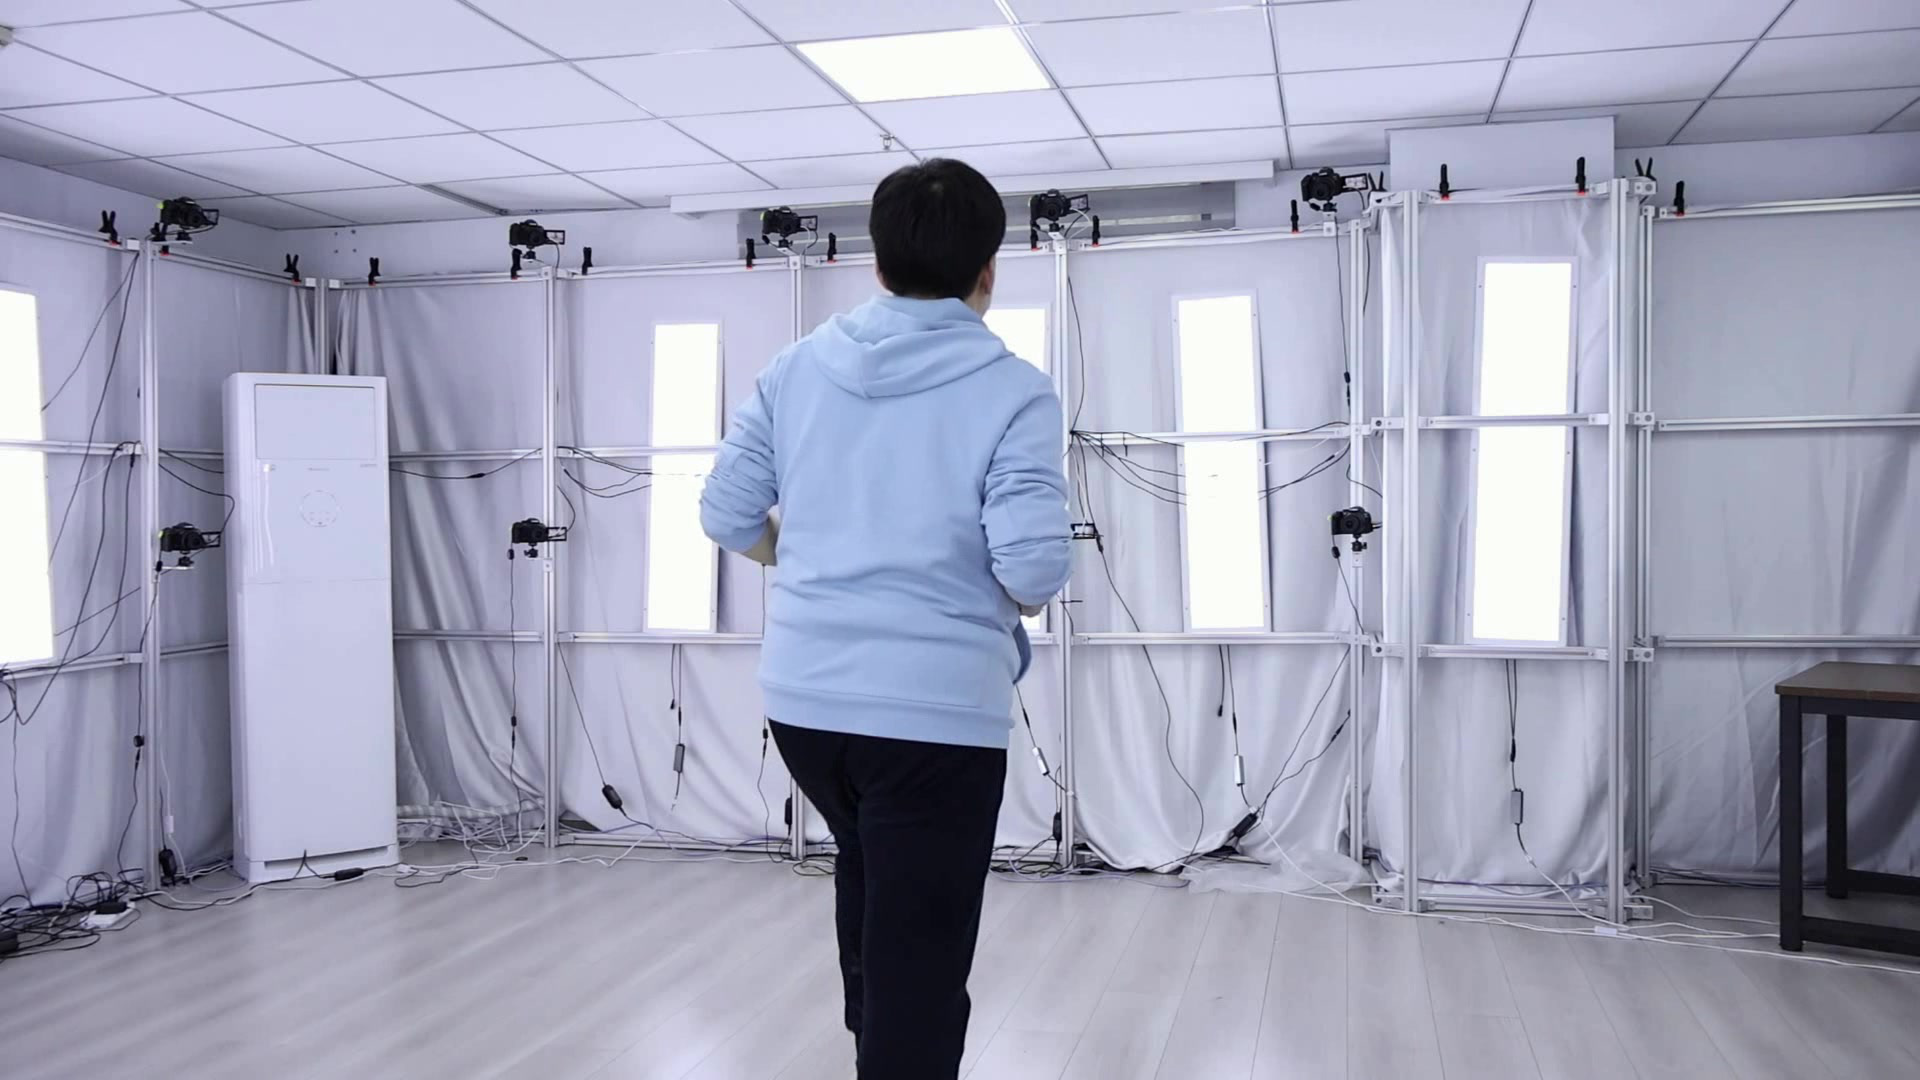

In [23]:
image

# Run pre-defined tasks that requires additional inputs
## Phrase Grounding

In [ ]:
task_prompt = '<CAPTION_TO_PHRASE_GROUNDING>'
text_prompt = 'The person rolls the peanut-shaped yoga ball on the ground, then places the rubber duck on top of the peanut-shaped yoga ball.'
results = run_example(task_prompt, text_input=text_prompt)
pprint.pprint(results)
labels = results[task_prompt]['labels']
for i, label in enumerate(labels):
    if label == 'The person' or label == 'A person':
        person_index = i
        break
print(f'bbox : {results[task_prompt]["bboxes"][person_index]}')

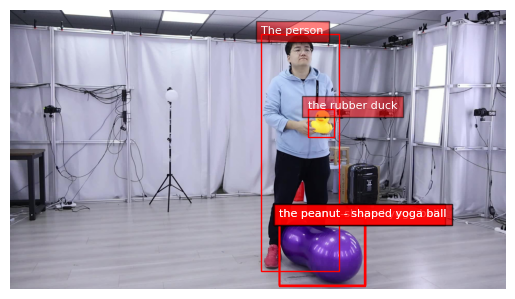

In [22]:
plot_bbox(image, results['<CAPTION_TO_PHRASE_GROUNDING>'])

## Open vocabulary detection

In [28]:
task_prompt = '<OPEN_VOCABULARY_DETECTION>'
results = run_example_with_score(task_prompt, text_input="shoes <and> upper cloth <and> trousers")
pprint.pprint(results)

{'<OPEN_VOCABULARY_DETECTION>': {'bboxes': [[692.1599731445312,
                                             156.0600128173828,
                                             1081.919921875,
                                             1075.1400146484375],
                                            [692.1599731445312,
                                             156.0600128173828,
                                             1080.0,
                                             1075.1400146484375],
                                            [761.2799682617188,
                                             714.4200439453125,
                                             1014.719970703125,
                                             1076.2200927734375]],
                                 'bboxes_labels': ['shoes',
                                                   'upper cloth',
                                                   'trousers'],
                                 'polygons': [],


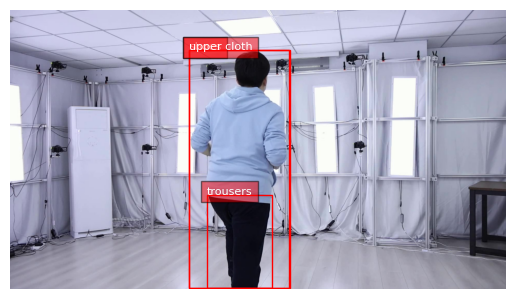

In [25]:
bbox_results  = convert_to_od_format(results['<OPEN_VOCABULARY_DETECTION>'])
plot_bbox(image, bbox_results)

## Object Detection

In [15]:
task_prompt = '<OD>'
results = run_example_with_score(task_prompt)
pprint.pprint(results)

{'<OD>': {'bboxes': [[757.4400024414062,
                      970.3800659179688,
                      845.760009765625,
                      1079.4600830078125],
                     [649.9199829101562,
                      151.74000549316406,
                      1110.719970703125,
                      1076.2200927734375],
                     [734.3999633789062,
                      724.1400146484375,
                      1007.0399780273438,
                      1071.9000244140625]],
          'labels': ['footwear', 'person', 'trousers'],
          'scores': [0.609696277710336,
                     0.37851617190985754,
                     0.41518794200003384]}}


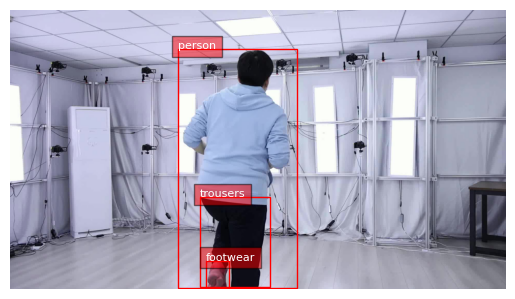

In [16]:
plot_bbox(image, results['<OD>'])

## Caption

In [26]:
task_prompt = '<DETAILED_CAPTION>'
run_example(task_prompt)

Generated Text:
['</s><s>The image shows a man in a blue sweatshirt and black pants standing in front of a white room with a table on the right side, wires and a white object in the middle, and lights attached to the ceiling. He appears to be in the process of building a virtual reality room.</s>']


{'<DETAILED_CAPTION>': 'The image shows a man in a blue sweatshirt and black pants standing in front of a white room with a table on the right side, wires and a white object in the middle, and lights attached to the ceiling. He appears to be in the process of building a virtual reality room.'}

## With supervision

In [31]:
import torch
import supervision as sv
from PIL import Image
from transformers import AutoProcessor, AutoModelForCausalLM  

In [32]:
model_id = 'microsoft/Florence-2-large'
model = AutoModelForCausalLM.from_pretrained(model_id, trust_remote_code=True, torch_dtype='auto').eval().cuda()
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)

In [ ]:
image_path = '/home/hlp/data/vton_test/images/02/ori_imgs/000019.jpg'
image = Image.open(image_path)
inputs = processor(images=image, return_tensors="pt")
text_input = "shoes <and> upper cloth <and> trousers"
task_prompt = '<OPEN_VOCABULARY_DETECTION>'
if text_input is None:
    prompt = task_prompt
else:
    prompt = task_prompt + text_input
inputs = processor(text=prompt, images=image, return_tensors="pt").to(device, torch_dtype)
generated_ids = model.generate(
    input_ids=inputs["input_ids"],
    pixel_values=inputs["pixel_values"],
    max_new_tokens=1024,
    num_beams=3,
    return_dict_in_generate=True,
    output_scores=True,
)
generated_text = processor.batch_decode(generated_ids.sequences, skip_special_tokens=False)[0]
print(processor.batch_decode(generated_ids.sequences, skip_special_tokens=False))
prediction, scores, beam_indices = generated_ids.sequences, generated_ids.scores, generated_ids.beam_indices
print(f'prediction: {prediction}')
print(f'scores: {scores}')
print(f'beam_indices: {beam_indices}')
transition_beam_scores = model.compute_transition_scores(
    sequences=prediction,
    scores=scores,
    beam_indices=beam_indices,
)
print(f'transition_beam_scores: {transition_beam_scores}')
parsed_answer = processor.post_process_generation(sequence=generated_ids.sequences[0],
    transition_beam_score=transition_beam_scores[0],
    task=task_prompt, image_size=(image.width, image.height)
)
print(f'parsed_answer: {parsed_answer}')
# with torch.no_grad():
#     outputs = model(**inputs)

['</s><s>shoes<loc_360><loc_144><loc_563><loc_995>upper cloth<loc_360><loc_144><loc_562><loc_995>trousers<loc_396><loc_661><loc_528><loc_996></s>']
prediction: tensor([[    2,     0,  1193,  8013, 50629, 50413, 50832, 51264, 34849, 21543,
         50629, 50413, 50831, 51264,    90, 21233,   268, 50665, 50930, 50797,
         51265,     2]], device='cuda:0')
scores: (tensor([[0., -inf, -inf,  ..., -inf, -inf, -inf],
        [0., -inf, -inf,  ..., -inf, -inf, -inf],
        [0., -inf, -inf,  ..., -inf, -inf, -inf]], device='cuda:0'), tensor([[ -1.4417, -30.5257, -24.2035,  ..., -23.7191, -22.4730, -29.7005],
        [ -1.4417, -30.5257, -24.2035,  ..., -23.7191, -22.4730, -29.7005],
        [ -1.4417, -30.5257, -24.2035,  ..., -23.7191, -22.4730, -29.7005]],
       device='cuda:0'), tensor([[-30.9375, -36.0078, -31.6660,  ..., -30.0313, -31.8516, -35.5005],
        [ -1.4298, -30.5265, -24.2072,  ..., -23.7189, -22.4689, -29.6994],
        [-30.6944, -34.9531, -26.4571,  ..., -25.7539, -

# SAM2

In [23]:
import sam2

In [2]:
import torch
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

In [3]:
import torch
from sam2.sam2_image_predictor import SAM2ImagePredictor

predictor = SAM2ImagePredictor.from_pretrained("facebook/sam2-hiera-large")

/home/hlp/.conda/envs/sam2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [36]:
predictor.set_image(image)
input_box = np.array([972.47998046875,
                                               93.42000579833984,
                                               1273.919921875,
                                               1008.1800537109375])

masks, scores, _ = predictor.predict(
    point_coords=None,
    point_labels=None,
    box=input_box[None, :],
    multimask_output=False,
)
show_masks(image, masks, scores, box_coords=input_box)

AttributeError: 'SAM2VideoPredictor' object has no attribute 'set_image'

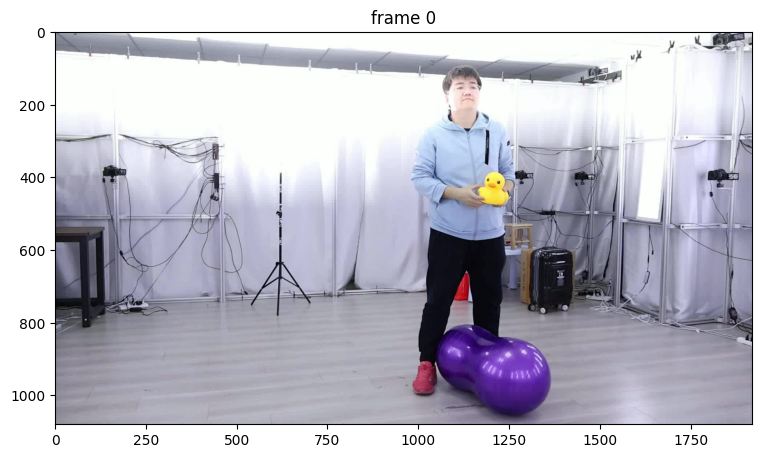

In [31]:
from sam2.sam2_video_predictor import SAM2VideoPredictor

predictor = SAM2VideoPredictor.from_pretrained("facebook/sam2-hiera-large")


video_dir = "/nas_data/dataset/4dhoi/25_04_03/person00/motion07/images/16/ori_imgs"

frame_names = [
    p for p in os.listdir(video_dir)
    if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
]

frame_names.sort(key=lambda p: int(os.path.splitext(p)[0]))

frame_idx = 0
plt.figure(figsize=(9, 6))
plt.title(f"frame {frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[frame_idx])))

In [35]:
inference_state = predictor.init_state(video_path=video_dir)
# predictor.reset_state(inference_state)

frame loading (JPEG): 100%|██████████| 471/471 [00:31<00:00, 14.97it/s]


In [49]:
# for video vis
def show_mask(mask, ax, obj_id=None, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap("tab10")
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_points(coords, labels, ax, marker_size=200):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)


def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))

def save_mask(mask):
    mask_image_data = np.squeeze((mask.astype(np.uint8) * 255))
    image = Image.fromarray(mask_image_data)
    image.save("mask.png")


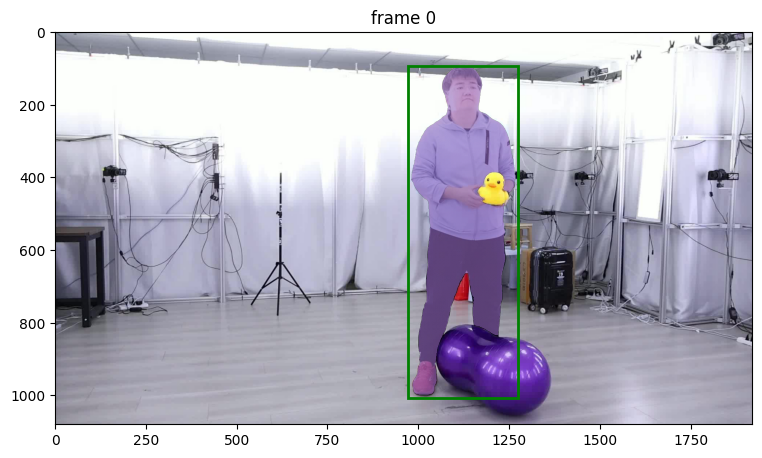

In [41]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 4  # give a unique id to each object we interact with (it can be any integers)

# Let's add a box at (x_min, y_min, x_max, y_max) = (300, 0, 500, 400) to get started
box = np.array([972.47998046875,
                                               93.42000579833984,
                                               1273.919921875,
                                               1008.1800537109375], dtype=np.float32)
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    box=box,
)

# show the results on the current (interacted) frame
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
show_box(box, plt.gca())
show_mask((out_mask_logits[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[0])

propagate in video:   0%|          | 0/471 [00:00<?, ?it/s]/nas_data/home/hlp/code/4dhoi/HOI_Gen/pre_processing/sam2/sam2/sam2_video_predictor.py:786: UserWarning: /nas_data/home/hlp/code/4dhoi/HOI_Gen/pre_processing/sam2/sam2/_C.so: undefined symbol: _ZN3c106detail23torchInternalAssertFailEPKcS2_jS2_RKNSt7__cxx1112basic_stringIcSt11char_traitsIcESaIcEEE

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
propagate in video: 100%|██████████| 471/471 [02:05<00:00,  3.75it/s]


TypeError: Cannot handle this data type: (1, 1, 1920), |u1

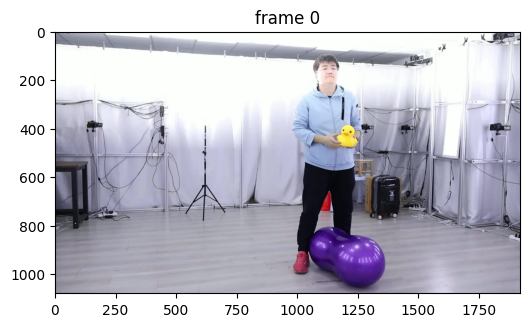

In [46]:
# run propagation throughout the video and collect the results in a dict
video_segments = {}  # video_segments contains the per-frame segmentation results
for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
    video_segments[out_frame_idx] = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }

# render the segmentation results every few frames
vis_frame_stride = 30
plt.close("all")
for out_frame_idx in range(0, len(frame_names), vis_frame_stride):
    plt.figure(figsize=(6, 4))
    plt.title(f"frame {out_frame_idx}")
    plt.imshow(Image.open(os.path.join(video_dir, frame_names[out_frame_idx])))
    for out_obj_id, out_mask in video_segments[out_frame_idx].items():
        save_mask(out_mask)
        show_mask(out_mask, plt.gca(), obj_id=out_obj_id)

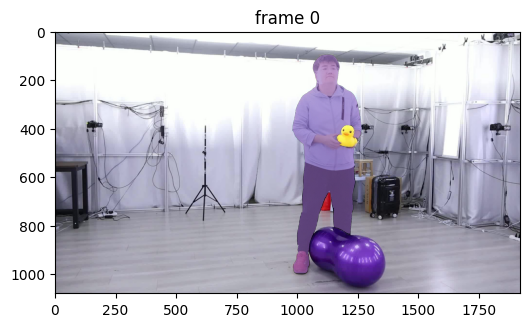

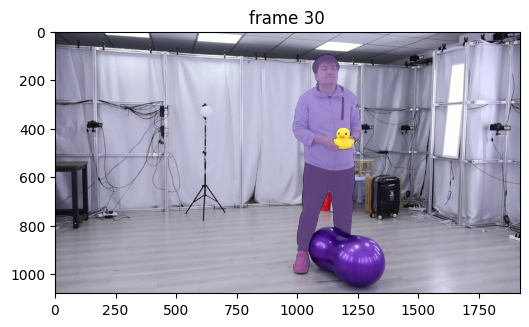

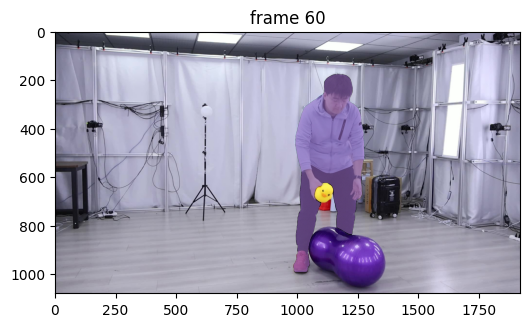

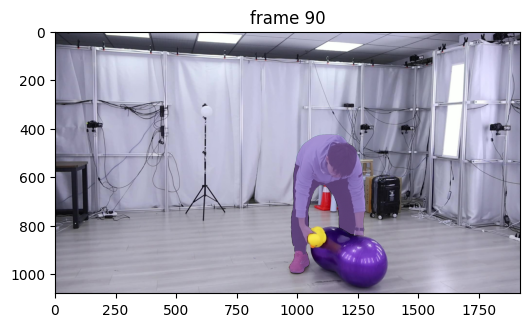

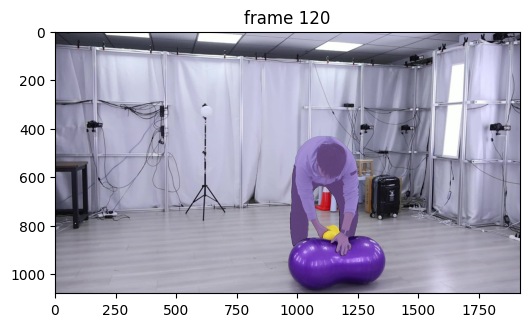

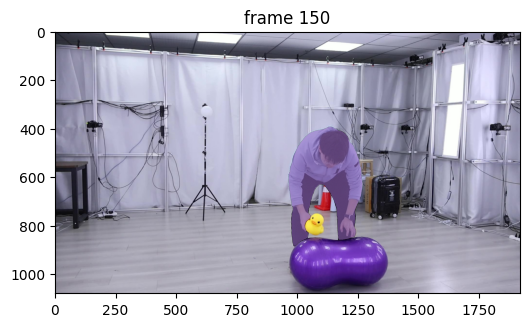

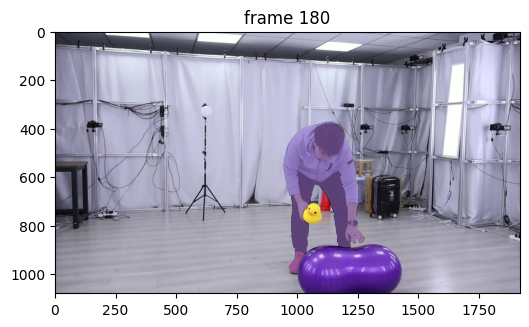

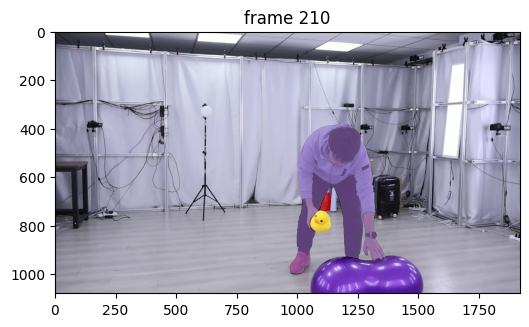

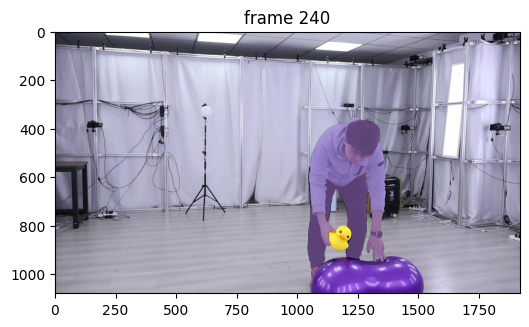

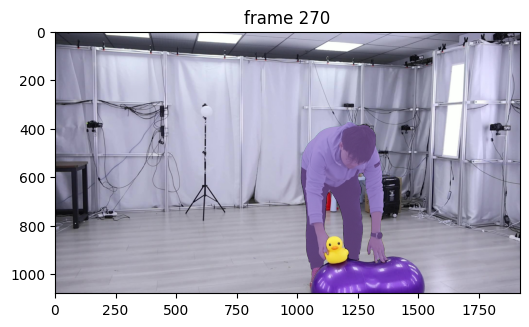

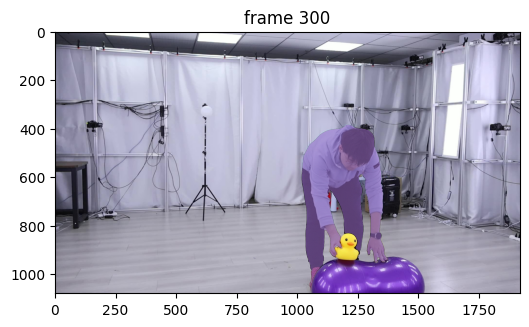

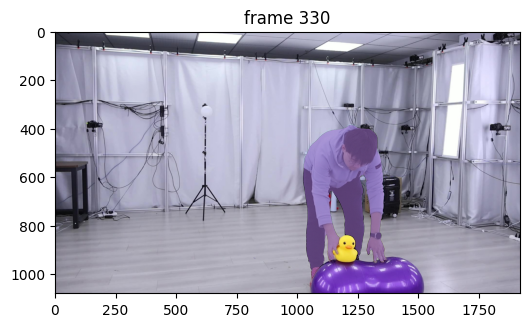

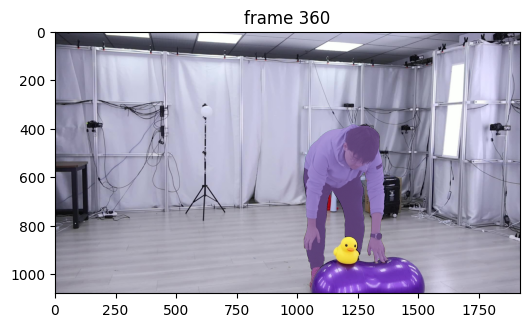

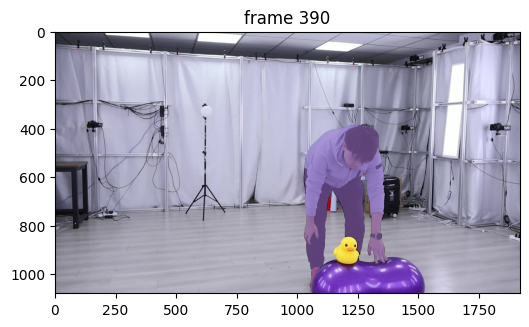

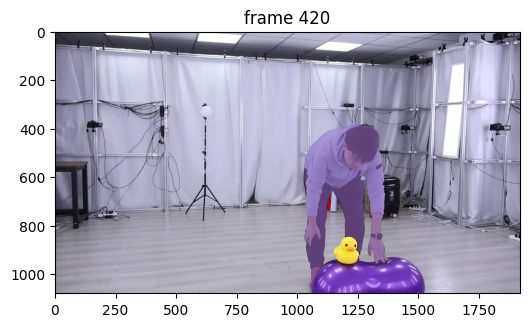

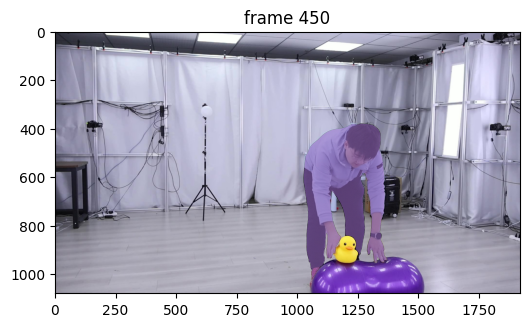

In [50]:
# render the segmentation results every few frames
vis_frame_stride = 30
plt.close("all")
for out_frame_idx in range(0, len(frame_names), vis_frame_stride):
    plt.figure(figsize=(6, 4))
    plt.title(f"frame {out_frame_idx}")
    plt.imshow(Image.open(os.path.join(video_dir, frame_names[out_frame_idx])))
    for out_obj_id, out_mask in video_segments[out_frame_idx].items():
        # print(out_mask.shape)
        save_mask(out_mask)
        show_mask(out_mask, plt.gca(), obj_id=out_obj_id)

In [53]:
from pathlib import Path
from typing import List, Union, Literal

def read_txt(path: Union[str, Path],
             mode: Literal["text", "lines"] = "text",
             encoding: str = "utf-8") -> Union[str, List[str]]:
    """
    读取 txt 文件

    参数
    ----
    path      : 文件路径
    mode      : "text" 返回无换行符的完整字符串；
                "lines" 返回去除换行符的行列表
    encoding  : 文件编码，默认 utf-8
    """
    path = Path(path).expanduser().resolve()
    if not path.is_file():
        raise FileNotFoundError(f"文件不存在: {path}")

    with path.open("r", encoding=encoding) as f:
        if mode == "text":
            # 一次性读取后删除所有换行符并返回
            return f.read().replace("\n", "").replace("\r", "")
        elif mode == "lines":
            # 逐行读取并去掉每行末尾的换行符
            return [line.rstrip("\n\r") for line in f]
        else:
            raise ValueError('mode 只能取 "text" 或 "lines"')


In [54]:
read_txt("/nas_data/dataset/4dhoi/25_04_03/person00/motion07/motion_text.txt")

'The person rolls the peanut-shaped yoga ball on the ground, then places the rubber duck on top of the ball.'

In [57]:
image_dir = Path("/nas_data/dataset/4dhoi/25_04_03/person00/motion07/images/16/ori_imgs")
frame_names = sorted(image_dir.glob("*.jpg"))
for i, fname in enumerate(frame_names):
    print(f"frame {i}: {fname.name}")

frame 0: 000000.jpg
frame 1: 000001.jpg
frame 2: 000002.jpg
frame 3: 000003.jpg
frame 4: 000004.jpg
frame 5: 000005.jpg
frame 6: 000006.jpg
frame 7: 000007.jpg
frame 8: 000008.jpg
frame 9: 000009.jpg
frame 10: 000010.jpg
frame 11: 000011.jpg
frame 12: 000012.jpg
frame 13: 000013.jpg
frame 14: 000014.jpg
frame 15: 000015.jpg
frame 16: 000016.jpg
frame 17: 000017.jpg
frame 18: 000018.jpg
frame 19: 000019.jpg
frame 20: 000020.jpg
frame 21: 000021.jpg
frame 22: 000022.jpg
frame 23: 000023.jpg
frame 24: 000024.jpg
frame 25: 000025.jpg
frame 26: 000026.jpg
frame 27: 000027.jpg
frame 28: 000028.jpg
frame 29: 000029.jpg
frame 30: 000030.jpg
frame 31: 000031.jpg
frame 32: 000032.jpg
frame 33: 000033.jpg
frame 34: 000034.jpg
frame 35: 000035.jpg
frame 36: 000036.jpg
frame 37: 000037.jpg
frame 38: 000038.jpg
frame 39: 000039.jpg
frame 40: 000040.jpg
frame 41: 000041.jpg
frame 42: 000042.jpg
frame 43: 000043.jpg
frame 44: 000044.jpg
frame 45: 000045.jpg
frame 46: 000046.jpg
frame 47: 000047.jpg
fr